In [2]:
import os, zipfile
import numpy as np
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

from google.colab import drive
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Extracted:", os.listdir(BASE))

Mounted at /content/drive
Extracted: ['New hand pd Dataset', 'Hand Pd']


In [3]:
!pip -q install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.9 MB/s eta 0:00:00


In [4]:
import imagehash
from PIL import Image
from collections import defaultdict

HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
SPIRAL_ROOT = os.path.join(HANDPD_ROOT, "Spiral_HandPD")
MEANDER_ROOT = os.path.join(HANDPD_ROOT, "Meander_HandPD")

image_paths = []
labels = []

def collect_handpd(root):
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue

        cls_lower = cls.lower()
        if cls_lower == "healthy":
            lab = 0
        elif cls_lower == "parkinson":
            lab = 1
        else:
            continue

        for r, d, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    image_paths.append(os.path.join(r, f))
                    labels.append(lab)

collect_handpd(SPIRAL_ROOT)
collect_handpd(MEANDER_ROOT)

print("Raw HandPD Total:", len(image_paths))
print("Healthy:", labels.count(0))
print("Parkinson:", labels.count(1))

Raw HandPD Total: 808
Healthy: 216
Parkinson: 592


In [5]:
def get_phash(img_path):
    try:
        img = Image.open(img_path).convert("L").resize((224,224))
        return imagehash.phash(img)
    except:
        return None

PHASH_DISTANCE_THRESHOLD = 4

hash_to_paths = defaultdict(list)

for p in tqdm(image_paths, desc="Hashing"):
    h = get_phash(p)
    if h is not None:
        hash_to_paths[str(h)].append(p)

hash_list = list(hash_to_paths.keys())
used = set()
final_keep = []

for i in tqdm(range(len(hash_list)), desc="Removing duplicates"):
    if hash_list[i] in used:
        continue

    base_hash = imagehash.hex_to_hash(hash_list[i])
    used.add(hash_list[i])
    final_keep.append(hash_list[i])

    for j in range(i+1, len(hash_list)):
        if hash_list[j] in used:
            continue
        compare_hash = imagehash.hex_to_hash(hash_list[j])
        if base_hash - compare_hash <= PHASH_DISTANCE_THRESHOLD:
            used.add(hash_list[j])

path_to_label = dict(zip(image_paths, labels))

clean_paths = []
clean_labels = []

for h in final_keep:
    p = hash_to_paths[h][0]
    clean_paths.append(p)
    clean_labels.append(path_to_label[p])

print("\nCLEAN HANDPD")
print("Images:", len(clean_paths))
print("Healthy:", clean_labels.count(0))
print("Parkinson:", clean_labels.count(1))

Removing duplicates: 100%|██████████| 735/735 [00:06<00:00, 119.14it/s]


CLEAN HANDPD
Images: 558
Healthy: 123
Parkinson: 435


In [6]:
paths = np.array(clean_paths)
labels = np.array(clean_labels)

train_paths, test_paths, y_train, y_test = train_test_split(
    paths, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    test_paths, y_test,
    test_size=0.50,
    random_state=42,
    stratify=y_test
)

print("Train:", Counter(y_train))
print("Val  :", Counter(y_val))
print("Test :", Counter(y_test))

Train: Counter({np.int64(1): 348, np.int64(0): 98})
Val  : Counter({np.int64(1): 44, np.int64(0): 12})
Test : Counter({np.int64(1): 43, np.int64(0): 13})


In [7]:


IMG_SIZE = 224
BATCH_SIZE = 16

def preprocess(path):
    path = path.numpy().decode()

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE only (no denoise, no heavy filters)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)

    return img


def tf_preprocess(path, label):
    img = tf.py_function(preprocess, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    label = tf.cast(label, tf.float32)
    return img, label



from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.1),
], name="augmentation")



def make_train_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(2000)
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)


    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def make_eval_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_train_ds(train_paths, y_train)
val_ds   = make_eval_ds(val_paths, y_val)
test_ds  = make_eval_ds(test_paths, y_test)

print("tf.data pipeline ready ")

tf.data pipeline ready 


In [8]:
print("Train distribution :", Counter(y_train))
print("Val distribution   :", Counter(y_val))
print("Test distribution  :", Counter(y_test))

Train distribution : Counter({np.int64(1): 348, np.int64(0): 98})
Val distribution   : Counter({np.int64(1): 44, np.int64(0): 12})
Test distribution  : Counter({np.int64(1): 43, np.int64(0): 13})


In [9]:
import numpy as np

def check_distribution(dataset, name):
    counts = {0: 0, 1: 0}

    for _, labels in dataset:
        labels_np = labels.numpy()
        counts[0] += np.sum(labels_np == 0)
        counts[1] += np.sum(labels_np == 1)

    print(f"{name} distribution:", counts)

check_distribution(train_ds, "Train")
check_distribution(val_ds, "Val")
check_distribution(test_ds, "Test")

Train distribution: {0: np.int64(98), 1: np.int64(348)}
Val distribution: {0: np.int64(12), 1: np.int64(44)}
Test distribution: {0: np.int64(13), 1: np.int64(43)}


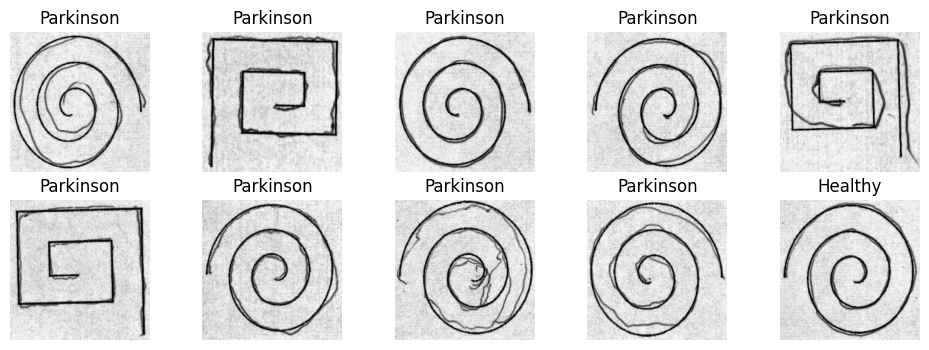

In [10]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()

    plt.figure(figsize=(12,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title("Healthy" if labels[i]==0 else "Parkinson")
        plt.axis("off")
    plt.show()

In [11]:
for imgs, _ in train_ds.take(1):
    print("Min:", imgs.numpy().min())
    print("Max:", imgs.numpy().max())

Min: 0.0
Max: 1.0121725


In [12]:
import random

TARGET_PER_CLASS = 1000


healthy_paths = train_paths[y_train == 0]
parkinson_paths = train_paths[y_train == 1]

print("\nOriginal Train Distribution")
print("Healthy:", len(healthy_paths))
print("Parkinson:", len(parkinson_paths))


def oversample_class(paths, target_size):
    paths = list(paths)
    current_size = len(paths)

    if current_size >= target_size:
        return paths[:target_size]

    extra_needed = target_size - current_size
    extra_samples = random.choices(paths, k=extra_needed)

    return paths + extra_samples



healthy_balanced = oversample_class(healthy_paths, TARGET_PER_CLASS)
parkinson_balanced = oversample_class(parkinson_paths, TARGET_PER_CLASS)


train_paths_balanced = np.array(healthy_balanced + parkinson_balanced)
y_train_balanced = np.array([0]*TARGET_PER_CLASS + [1]*TARGET_PER_CLASS)


indices = np.arange(len(train_paths_balanced))
np.random.shuffle(indices)

train_paths_balanced = train_paths_balanced[indices]
y_train_balanced = y_train_balanced[indices]

print("\nAfter Oversampling")
print("Train Balanced:", Counter(y_train_balanced))
print("Total Train Size:", len(train_paths_balanced))


Original Train Distribution
Healthy: 98
Parkinson: 348

After Oversampling
Train Balanced: Counter({np.int64(1): 1000, np.int64(0): 1000})
Total Train Size: 2000


In [13]:
print("\nLeakage Check")
print("Train-Val overlap :", len(set(train_paths_balanced) & set(val_paths)))
print("Train-Test overlap:", len(set(train_paths_balanced) & set(test_paths)))
print("Val-Test overlap  :", len(set(val_paths) & set(test_paths)))


Leakage Check
Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0


In [14]:
train_ds = make_train_ds(train_paths_balanced, y_train_balanced)
val_ds   = make_eval_ds(val_paths, y_val)
test_ds  = make_eval_ds(test_paths, y_test)

print("Final dataset ready ")

Final dataset ready 


In [15]:
from tensorflow.keras import layers
from tensorflow import keras

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
EMBED_DIM = 256

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)
        x = tf.reshape(x, [tf.shape(x)[0], -1, EMBED_DIM])
        return x

class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        cls = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        self.norm2 = layers.LayerNormalization()
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [16]:
# ======================================
# CELL 8 — Exact Requested Architecture
# ======================================

from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf

PATCH_SIZE = 16
EMBED_DIM = 526
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2


# -------- Patch Embedding --------
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)  # (B, 14, 14, 526)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])  # (B, 196, 526)
        return x


# -------- Add CLS + Position Embedding --------
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.repeat(self.cls_token, repeats=batch_size, axis=0)
        x = tf.concat([cls_tokens, x], axis=1)  # (B,197,526)
        return x + self.pos_embed


# -------- Transformer Encoder Block --------
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# -------- Build Model --------
def build_exact_vit():

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Patch embedding
    x = PatchEmbedding(PATCH_SIZE, EMBED_DIM)(inputs)

    # Add CLS token + positional embedding
    x = AddPositionEmbedding(NUM_PATCHES, EMBED_DIM)(x)

    # 6 Transformer blocks
    for _ in range(6):
        x = TransformerEncoder(
            embed_dim=EMBED_DIM,
            num_heads=8,
            mlp_dim=1024
        )(x)

    # Final normalization
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Take CLS token from LAST transformer layer
    cls_token_output = x[:, 0]   # (B, 526)

    # Single Dense classification layer
    x = layers.Dense(128, activation="relu")(cls_token_output)

    # Final output (2 classes)
    outputs = layers.Dense(2, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model


vit_model = build_exact_vit()
vit_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding          │ (None, 197, 526)       │       104,148 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 197, 526)       │     2,177,068 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 197, 526)       │     2,177,068 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 197, 526)       │     2,177,068 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 197, 526)       │     2,177,068 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_4           │ (None, 197, 526)       │     2,177,068 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_5           │ (None, 197, 526)       │     2,177,068 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_12          │ (None, 197, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 526)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        67,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,370,504 (51.00 MB)

 Trainable params: 13,370,504 (51.00 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60
)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 243ms/step - accuracy: 0.4818 - loss: 1.0957 - val_accuracy: 0.2143 - val_loss: 0.7532
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 210ms/step - accuracy: 0.5077 - loss: 0.7150 - val_accuracy: 0.7857 - val_loss: 0.6333
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 219ms/step - accuracy: 0.4807 - loss: 0.7174 - val_accuracy: 0.7857 - val_loss: 0.5886
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 230ms/step - accuracy: 0.5218 - loss: 0.7036 - val_accuracy: 0.7857 - val_loss: 0.6202
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 230ms/step - accuracy: 0.5036 - loss: 0.7046 - val_accuracy: 0.2143 - val_loss: 0.8250
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - accuracy: 0.4991 - loss: 0.7063 - val_accuracy: 0.2143 - val_loss: 0.7205
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 225ms/step - accuracy: 0.5041 - loss: 0.7212 - val_accuracy: 0.2143 - val_loss: 0.8261
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 221ms/step - accuracy: 0.5110 - loss: 0